# Assignment #3: Analyzing Drug Reviews

## Goals
- Clean and combine review text from **benefitsReview**, **sideEffectsReview**, and **commentsReview** to form an overall patient satisfaction review.
- Convert numeric **rating** into **class labels**.
- Analyze distribution of rating, average ratings per condition and per drugs.
- Use vader sentiment analysis and calculate accuracy of sentiment classification.
- generate word clouds and bar plots of most distinctive terms from positive and negative reviews.
- Use Bio_clinicalBERT transformer for sentiment classification.

<b> Total: 100pts



## Part I: Exploratory Data Analysis (40pts)

Install/Import libraries you need.

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


Load Data


In [ ]:
train_df=pd.read_csv("drugLibTrain_raw.tsv", sep="\t")
test_df=pd.read_csv("drugLibTest_raw.tsv", sep="\t")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (3107, 9)
Test shape: (1036, 9)


,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


### Create the **Overall Patient Satisfaction Review**
Concatenate *benefitsReview + sideEffectsReview + commentsReview* into a single field `overall_review`.

In [ ]:
#creating a field called overall_review for both train and test set
train_df["overall_review"] = (
    train_df["benefitsReview"].fillna("") + " " +
    train_df["sideEffectsReview"].fillna("") + " " +
    train_df["commentsReview"].fillna("")
)


test_df["overall_review"] = (
    test_df["benefitsReview"].fillna("") + " " +
    test_df["sideEffectsReview"].fillna("") + " " +
    test_df["commentsReview"].fillna("")
)

# Preview
train_df[["benefitsReview", "sideEffectsReview", "commentsReview", "overall_review"]].head()


,benefitsReview,sideEffectsReview,commentsReview,overall_review
0,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ...",slowed the progression of left ventricular dys...
1,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest...",Although this type of birth control has more c...
2,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...,I was used to having cramps so badly that they...
3,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...,The acid reflux went away for a few months aft...
4,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above,I think that the Lyrica was starting to help w...


### Convert **rating** to 2-Class Labels
Rules (as requested):
- `positive` if rating >5
- `negative` if rating <= 5


In [ ]:
#creating new field for rules
train_df['label']=train_df['rating'].apply(lambda x: 'positive' if x>5 else 'negative')
test_df['label']=test_df['rating'].apply(lambda x: 'positive' if x>5 else 'negative')

train_df.head()

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview,overall_review,label
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ...",slowed the progression of left ventricular dys...,negative
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest...",Although this type of birth control has more c...,negative
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...,I was used to having cramps so badly that they...,positive
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...,The acid reflux went away for a few months aft...,negative
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above,I think that the Lyrica was starting to help w...,negative


### 	Analyze distribution of ratings
Show a histogram of rating

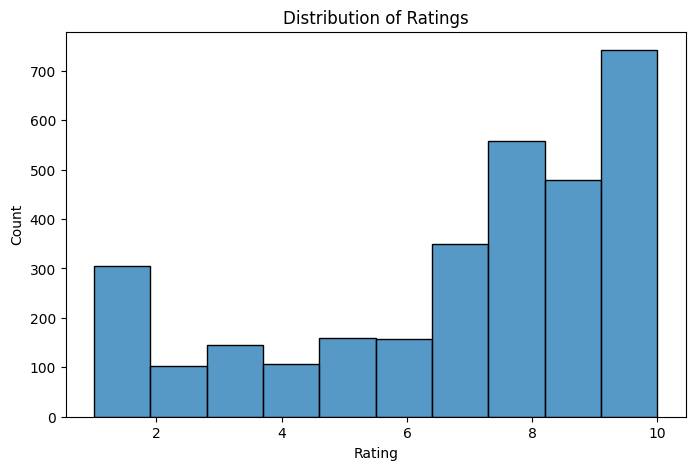

In [ ]:
# Distribution of ratings
plt.figure(figsize=(8,5))
sns.histplot(train_df["rating"], bins=10, kde=False)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


### Top conditions by review count bar plot

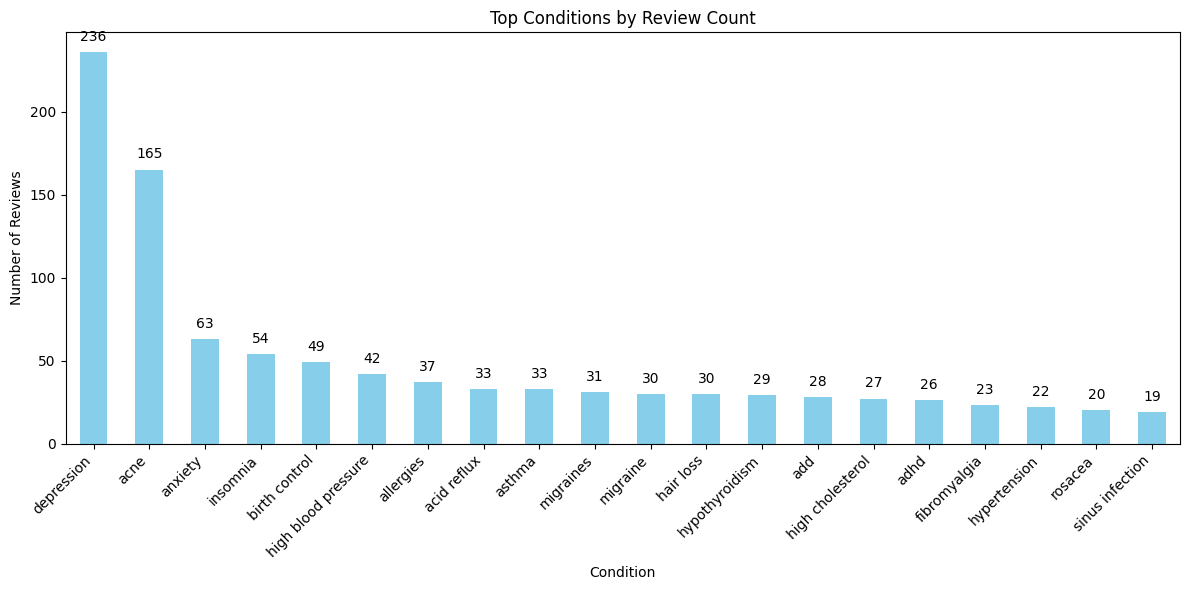

In [ ]:
plt.figure(figsize=(12,6))

# Get top 20 conditions and their counts
top_conditions = train_df["condition"].value_counts().head(20)

# Create bar chart
ax = top_conditions.plot(kind="bar", color='skyblue')

# Add counts on top of each bar
for i, count in enumerate(top_conditions):
    ax.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=10)

# Titles and labels
plt.title("Top Conditions by Review Count")
plt.xlabel("Condition")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha='right')  # Rotate x labels for readability
plt.tight_layout()
plt.show()



### Average rating by condition to see which conditions have better treatment satisfaction.


In [ ]:
condition_summary = (
    train_df.groupby("condition")
    .agg(
        count=("rating", "count"),
        avg_rating=("rating", "mean")
    )
    .sort_values(by="avg_rating", ascending=False)
)

condition_summary


,count,avg_rating
condition,,
vaginal dryness/bladder inflamation-irritations,1,10.0
"vaginal dryness, night sweats",1,10.0
uti prevention,1,10.0
urinary tract infrection,1,10.0
acne and anti age benefits,1,10.0
...,...,...
anxiety depression,1,1.0
vaginal eczema,1,1.0
viral bronchitis,1,1.0


In [ ]:
def search_condition_rating(condition_name):
    result = condition_summary.loc[condition_name] if condition_name in condition_summary.index else None

    if result is None:
        print("Condition not found.")
    else:
        print(f"Condition: {condition_name}")
        print(f"Average Rating: {result['avg_rating']:.2f}")
        print(f"Review Count: {result['count']}")


In [ ]:
search_condition_rating("uti prevention")


Condition: uti prevention
Average Rating: 10.00
Review Count: 1.0


### Top drugs by avg rating.

In [ ]:
drug_summary = (
    train_df.groupby("urlDrugName")
    .agg(
        count=("rating", "count"),
        avg_rating=("rating", "mean")
    )
    .sort_values(by="avg_rating", ascending=False)
)

drug_summary.head(100)



,count,avg_rating
urlDrugName,,
zestoretic,1,10.0
naltrexone,1,10.0
phendimetrazine,1,10.0
asmanex,1,10.0
atripla,1,10.0
...,...,...
klaron,2,9.0
emsam,3,9.0
requip,6,9.0


### Identify distinctive terms for high‑rating vs low‑rating reviews.

In [ ]:

train_df['actual_label'] = train_df['label']
test_df['actual_label'] = test_df['label']


df = train_df

In [ ]:
# TF‑IDF top terms helper
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=5, stop_words='english')

for label in ['positive','negative']:
    sub = df[df['actual_label'] == label]

    X = vectorizer.fit_transform(sub['overall_review'])
    terms = np.array(vectorizer.get_feature_names_out())
    tfidf_means = np.asarray(X.mean(axis=0)).ravel()
    top_idx = tfidf_means.argsort()[::-1][:20]
    print(f"Top terms for {label} ratings:")
    for t, v in zip(terms[top_idx], tfidf_means[top_idx]):
        print(f"{t:25s} {v:.4f}")

Top terms for positive ratings:
day                       0.0307
effects                   0.0269
taking                    0.0259
pain                      0.0259
drug                      0.0232
medication                0.0221
skin                      0.0220
treatment                 0.0198
time                      0.0198
did                       0.0191
days                      0.0185
mg                        0.0177
sleep                     0.0176
took                      0.0176
years                     0.0170
daily                     0.0166
night                     0.0161
pill                      0.0159
feel                      0.0159
dose                      0.0149
Top terms for negative ratings:
pain                      0.0374
drug                      0.0343
day                       0.0336
effects                   0.0335
taking                    0.0320
did                       0.0309
medication                0.0256
severe                    0.0244
took        

### Word clouds

In [ ]:
!pip install wordcloud


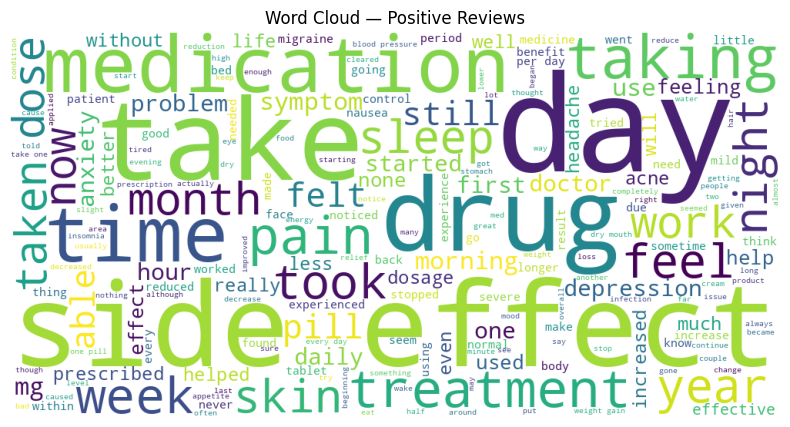

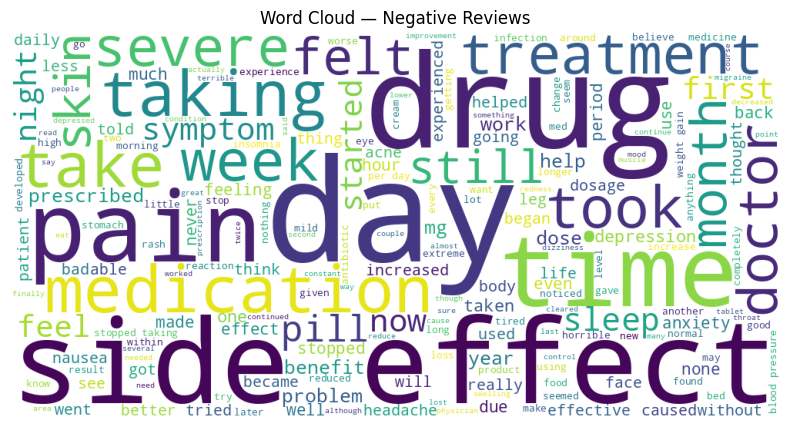

In [ ]:
from wordcloud import WordCloud

wc = WordCloud(width=1000, height=500, background_color='white', max_words=200)

# Fixed: Remove .get() and use proper DataFrame indexing
text_positive = ' '.join(df[df['actual_label']=='positive']['overall_review'].tolist())
text_negative = ' '.join(df[df['actual_label']=='negative']['overall_review'].tolist())

if text_positive:
    plt.figure(figsize=(10,5))
    plt.imshow(wc.generate(text_positive))
    plt.axis('off')
    plt.title('Word Cloud — Positive Reviews')
    plt.show()

if text_negative:
    plt.figure(figsize=(10,5))
    plt.imshow(wc.generate(text_negative))
    plt.axis('off')
    plt.title('Word Cloud — Negative Reviews')
    plt.show()

## Part II: Sentiment Analysis & NLP (60pts)



### Use Vader sentiment analysis (20pts)
- apply vader SentimentIntensityAnalyzer on the overall_review.
- add the compound score to the dataframe.
- add vader_label column as 'positive' if compound >0 and negative otherwise.
- calculate the sentiment classification accuracy out of Vader.

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Apply VADER to BOTH train and test datasets
for dataset in [train_df, test_df]:
    dataset["vader_compound"] = dataset["overall_review"].apply(
        lambda x: sia.polarity_scores(str(x))["compound"]
    )
    dataset["vader_label"] = dataset["vader_compound"].apply(
        lambda x: "positive" if x > 0 else "negative"
    )

# Calculate accuracy for train set
train_vader_accuracy = (train_df["vader_label"] == train_df["actual_label"]).mean()
print(f"VADER Sentiment Classification Accuracy (Train): {train_vader_accuracy:.4f}")

# Calculate accuracy for test set
test_vader_accuracy = (test_df["vader_label"] == test_df["actual_label"]).mean()
print(f"VADER Sentiment Classification Accuracy (Test): {test_vader_accuracy:.4f}")


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


VADER Sentiment Classification Accuracy (Train): 0.5426
VADER Sentiment Classification Accuracy (Test): 0.5270


Calculate the accuracy score

In [ ]:
# Display in percentage format
print(f"VADER Training Accuracy: {train_vader_accuracy * 100:.2f}%")
print(f"VADER Test Accuracy: {test_vader_accuracy * 100:.2f}%")


VADER Training Accuracy: 54.26%
VADER Test Accuracy: 52.70%


### Sentiment Analysis using Bio_ClinicalBERT (30pts)


Use Bio_ClinicalBERT for sentiment analysis on the Drug Reviews dataset. Reuse the code below.
- Train/Test on the whole dataset
- Split the dataset into training/testing subsets
- Report the sentiment classification accuracy.



In [ ]:
!pip install -q transformers torch scikit-learn

In [ ]:
import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


MODEL_ID = "emilyalsentzer/Bio_ClinicalBERT"
tok = AutoTokenizer.from_pretrained(MODEL_ID)
mdl = AutoModel.from_pretrained(MODEL_ID).eval().to("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def encode_mean_safe(texts, batch_size=500, max_len=256):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        enc = tok(batch_texts, padding=True, truncation=True, max_length=max_len, return_tensors="pt")
        enc = {k: v.to(mdl.device) for k, v in enc.items()}
        with torch.no_grad():
            out = mdl(**enc).last_hidden_state
            attn = enc["attention_mask"].unsqueeze(-1)
            mean_emb = (out * attn).sum(1) / attn.sum(1).clamp_min(1e-9)
            embeddings.append(mean_emb.cpu().numpy())
    return np.vstack(embeddings)


In [ ]:

X_train_text = train_df["overall_review"].astype(str).tolist()
y_train = train_df["label"].tolist()

X_test_text = test_df["overall_review"].astype(str).tolist()
y_test = test_df["label"].t olist()

SyntaxError: invalid syntax (ipython-input-3235708267.py, line 5)

In [ ]:
X_train = encode_mean_safe(X_train_text, batch_size=500, max_len=256)
X_test = encode_mean_safe(X_test_text, batch_size=500, max_len=256)


In [ ]:

# Increased max_iter to avoid convergence warning
clf = make_pipeline(
    StandardScaler(with_mean=False),
    LogisticRegression(max_iter=1000, random_state=42)
)
clf.fit(X_train, y_train)

In [ ]:
# --- Function to get polarity score and label ---
def polarity_from_clinicalbert(text: str):
    if text is None or not str(text).strip():
        return 0.0, "neutral"
    emb = encode_mean_safe([text])
    prob = clf.predict_proba(emb)[0]  # [p_neg, p_pos] if binary
    score = prob[1] - prob[0]         # signed polarity in [-1, 1] approx
    label = "positive" if score > 0 else "negative"
    return float(score), label

In [ ]:
for df in [train_df, test_df]:
    scores_labels = df["overall_review"].apply(polarity_from_clinicalbert)
    df["clinicalbert_score"] = scores_labels.apply(lambda x: x[0])
    df["clinicalbert_label"] = scores_labels.apply(lambda x: x[1])


In [ ]:
for df in [train_df, test_df]:
    display(df[["overall_review", "clinicalbert_score", "clinicalbert_label"]].head())


In [ ]:
text= "slowed the progression of left ventricular dysfunction into overt heart failure alone or with other agents in the managment of hypertension mangagement of congestive heart failur cough, hypotension , proteinuria, impotence , renal failure , angina pectoris , tachycardia , eosinophilic pneumonitis, tastes disturbances , anusease anorecia , weakness fatigue insominca weakness monitor blood pressure , weight and asses for resolution of fluid"
print(polarity_from_clinicalbert(text))

In [ ]:
#model accuracy
from sklearn.metrics import accuracy_score

# For training set
train_acc = accuracy_score(train_df["label"], train_df["clinicalbert_label"])
print(f"Training Accuracy: {train_acc:.4f}")

# For test set
test_acc = accuracy_score(test_df["label"], test_df["clinicalbert_label"])
print(f"Test Accuracy: {test_acc:.4f}")


### Sentiment polarity score versus label Visualization (10pts)
- show the density plot of the compound score per actual_label
- show the density plot of the polarity_from_clinicalbert score per actual_label
- comment on the plots

In [1]:
df=train_df

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x="vader_compound", hue="actual_label", fill=True)
plt.title("Density of VADER Compound Scores by Actual Label")
plt.xlabel("VADER Compound Score")
plt.ylabel("Density")
plt.show()


NameError: name 'train_df' is not defined

In [ ]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x="clinicalbert_score", hue="actual_label", fill=True)
plt.title("Density of Bio_ClinicalBERT Polarity Scores by Actual Label")
plt.xlabel("ClinicalBERT Polarity Score")
plt.ylabel("Density")
plt.show()